# HIV Antibody Detection by ELISA — Result Analysis

**Technique:** Indirect Enzyme-Linked Immunosorbent Assay (ELISA)
**Objective:** Detect HIV-specific antibodies in serum samples by calculating an
assay cut-off from negative controls and classifying each patient sample's OD450
reading as Non-reactive, Reactive, or Equivocal.

---
## 1. Background

HIV antigens (e.g. gp41, gp120, p24) are immobilised on a microplate. If HIV-specific
antibodies are present in a patient's serum, they bind the antigen. An HRP-conjugated
anti-human IgG secondary antibody then binds the captured antibody, and a TMB substrate
produces a colour change proportional to bound antibody, read as optical density (OD)
at 450 nm.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sample_data/plate_results.csv")
df

,sample_id,sample_type,od450
0,NegControl_1,control,0.132
1,NegControl_2,control,0.148
2,NegControl_3,control,0.141
3,PosControl_1,control,1.582
4,PosControl_2,control,1.601
5,Patient_1,patient,0.112
6,Patient_2,patient,0.891
7,Patient_3,patient,0.238
8,Patient_4,patient,0.098
9,Patient_5,patient,1.203


## 2. Calculate the assay cut-off

Cut-off (CO) = mean OD of negative controls + 0.10 (per kit protocol convention).


In [2]:
CUTOFF_FACTOR = 0.10
EQUIVOCAL_MARGIN = 0.02

neg_controls = df[(df.sample_type == "control") & (df.sample_id.str.startswith("Neg"))]
cutoff = round(neg_controls.od450.mean() + CUTOFF_FACTOR, 3)
print(f"Negative control mean OD450: {neg_controls.od450.mean():.3f}")
print(f"Cut-off value: {cutoff}")

Negative control mean OD450: 0.140
Cut-off value: 0.24


## 3. Classify patient samples

In [3]:
def classify(od, cutoff, margin=EQUIVOCAL_MARGIN):
    if od >= cutoff + margin:
        return "Reactive"
    elif od <= cutoff - margin:
        return "Non-reactive"
    return "Equivocal"

patients = df[df.sample_type == "patient"].copy()
patients["result"] = patients.od450.apply(lambda x: classify(x, cutoff))
patients[["sample_id", "od450", "result"]]

,sample_id,od450,result
5,Patient_1,0.112,Non-reactive
6,Patient_2,0.891,Reactive
7,Patient_3,0.238,Equivocal
8,Patient_4,0.098,Non-reactive
9,Patient_5,1.203,Reactive
10,Patient_6,0.156,Non-reactive
11,Patient_7,0.244,Equivocal
12,Patient_8,0.077,Non-reactive


## 4. Visualise results against the cut-off

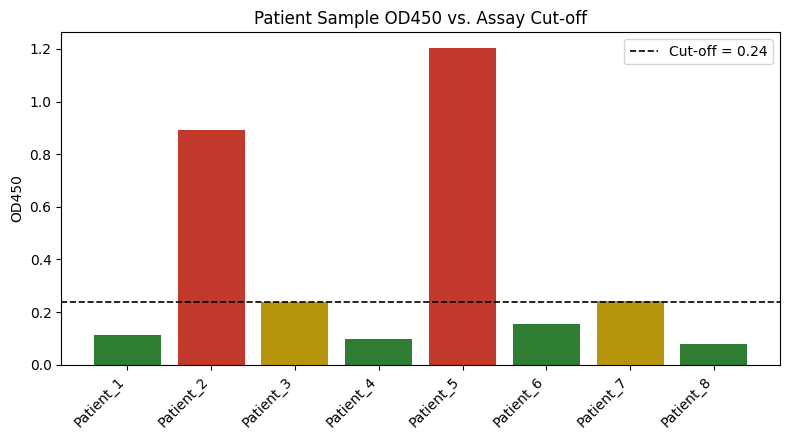

In [4]:
colors = patients.result.map({"Reactive": "#C0392B", "Non-reactive": "#2E7D32", "Equivocal": "#B7950B"})

plt.figure(figsize=(8, 4.5))
plt.bar(patients.sample_id, patients.od450, color=colors)
plt.axhline(cutoff, color="black", linestyle="--", linewidth=1.2, label=f"Cut-off = {cutoff}")
plt.ylabel("OD450")
plt.title("Patient Sample OD450 vs. Assay Cut-off")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig("elisa_results_plot.png", dpi=150)
plt.show()

## 5. Summary

In [5]:
reactive_count = (patients.result == "Reactive").sum()
equivocal_count = (patients.result == "Equivocal").sum()
nonreactive_count = (patients.result == "Non-reactive").sum()

print(f"Non-reactive: {nonreactive_count}")
print(f"Equivocal:    {equivocal_count}")
print(f"Reactive:     {reactive_count}")
print()
print("Note: Reactive results are presumptive only and require confirmatory testing")
print("(e.g. Western blot) before any diagnostic conclusion.")

Non-reactive: 4
Equivocal:    2
Reactive:     2

Note: Reactive results are presumptive only and require confirmatory testing
(e.g. Western blot) before any diagnostic conclusion.
